# Gradient Descent

given the **mathematics & computer science** test score summary of all the student as per csv file
find the correlation between their scores 

here; **x** = math and **y** = cs

__Linear Equation : <font color='green'>dependent variable</font> = <font color='orange'>slope/coefficient</font> * <font color='blue'>independent variable + <font color='red'>intercept/constant</font><br>__
y = m * x + b<br>

cs = m * math + b

In [1]:
import pandas as pd
from sklearn import linear_model
import numpy as np
import matplotlib.pyplot as plt
import math

df = pd.read_csv('test_scores.csv')
df.head

<bound method NDFrame.head of      name  math  cs
0   david    92  98
1   laura    56  68
2  sanjay    88  81
3     wei    70  80
4    jeff    80  83
5   aamir    49  52
6  venkat    65  66
7   virat    35  30
8  arthur    66  68
9    paul    67  73>

In [2]:
reg_model = linear_model.LinearRegression()
reg_model.fit(df[['math']], df.cs)
#print("Using scikit-learn: \nCoefficient {}, \nIntercept {}".format(reg_model.coef_, reg_model.intercept_))
#print("Using gradient descent function: \nCoefficient {}, \nIntercept {}".format(reg_model.coef_, reg_model.intercept_))

LinearRegression()

In [3]:
# df.math # mathematics test score

In [4]:
# df.cs # computer science test score

In [5]:
# df.name # students name

In [6]:
x = np.array(df.math) # store maths's test score values in an array using "numpy"
#x

In [7]:
y = np.array(df.cs) # store computer science's test score values in an array using "numpy"
#y

In [8]:
def student_test_score_gd(x, y):
    
    #print(x)
    #print(y)
    
    %matplotlib inline
    plt.xlabel('x', fontsize=20)
    plt.ylabel('y', fontsize=20)
    plt.scatter(x, y,color='red',linewidths=5,marker='+')
    plt.title('Student\'s test score',fontsize=20)
    plt.legend(title='Math & CS',loc='upper left')
    plt.grid()
    
    # linear equation : y = m * x + b
    # let start with randaom values of 'm' & 'b' nothing but slope/coefficient & intercept values respectively.
    m_curr = b_curr = 0
    
    iteration = 1000  # optimization loop count
    learning_rate = 0.0001 # need to adjust to get global minimaa
    n = len(x)       # length of independent variable
    mse_old = 0.0

    for i in range(iteration):
        
        y_predicted = m_curr*x + b_curr # linear equation : y = m * x + b
        plt.plot(x, y_predicted, color='green')
        
        # mean square error, calculation
        mse = (1/n) * sum([val ** 2 for val in (y - y_predicted)])
        
        # partial derivatives calculation
        m_parDeri = -(2/n) * sum(x * (y - y_predicted))
        b_parDeri = -(2/n) * sum(y - y_predicted)
        
        # set the learning rate
        m_curr = m_curr - learning_rate * m_parDeri
        b_curr = b_curr - learning_rate * b_parDeri
        
        #if(math.isclose(mse_old, mse, rel_tol=1e-20)):
        if(math.isclose(mse_old, mse, abs_tol=0.0001)):
            break
            
        mse_old = mse
        
        print("m {}, b {}, mse {}, iteration {}".format(m_curr,b_curr,mse,i))
        
    plt.plot(x, y_predicted, color='blue')
    print("\n")
    print("Using scikit-learn: Coefficient {}, \tIntercept {}".format(reg_model.coef_, reg_model.intercept_))
    print("Using gradient descent function: Coefficient {}, \tIntercept {}".format(m_curr, b_curr))
    print("\n")
    
    return m_curr, b_curr

No handles with labels found to put in legend.


m 0.9891800000000002, b 0.013980000000000001, mse 5199.1, iteration 0
m 1.0416176032, b 0.0147417592, mse 46.3330473650399, iteration 1
m 1.0443971065873279, b 0.014802799669408, mse 31.852649863558305, iteration 2
m 1.0445441606668626, b 0.014826693765467417, mse 31.811952059367805, iteration 3
m 1.0445516647187705, b 0.014848618440205038, mse 31.811832943358482, iteration 4


Using scikit-learn: Coefficient [1.01773624], 	Intercept 1.9152193111569176
Using gradient descent function: Coefficient 1.0445517710206773, 	Intercept 0.014870438475874223


________________________________________
name        math            cs             
________________________________________
david         92       96.113633
laura         56       58.509770
sanjay        88       91.935426
wei           70       73.133494
jeff          80       83.579012
aamir         49       51.197907
venkat        65       67.910736
virat         35       36.574182
arthur        66       68.955287
paul          67     

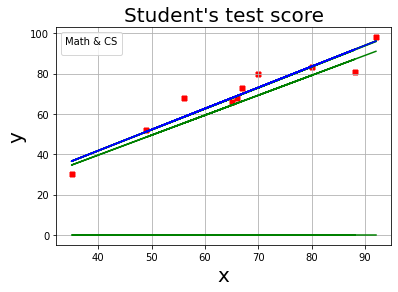

In [9]:
m, b = student_test_score_gd(x, y)
#l = len(x)
print("_"*40)
#print str.ljust(50,'_')
print('{:11s} {:15s} {:15s}'.format("name", "math", "cs"))
print("_"*40)
#print(str.ljust(50,'_'))

for i in range(len(x)):
    print("{:10s} {:5d} {:15f}".format(df.name[i], x[i], (x[i]*m + b)))
    
print('\n')
print(df)